## Support Vector machines
SVMs are widely used ML models that classify datapoints into categories by dividing them with a line (or hyperplane if data is has 3 or more dimensions). It finds the best separation line that has the largest gap between two categories. For this purpose the gradient descent is used to iteratively minimize the loss function. 

In [7]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_p=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_p
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # 1. Convert labels to -1 and 1
        y_ = np.where(y <= 0, -1, 1)
        
        # 2. Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0

        # 3. Gradient Descent
        for epoch in range(self.n_iters):
            for idx, x_i in enumerate(X):
                
                # Check the condition: y * (wx + b) >= 1
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    # Case A: Correctly classified outside margin
                    # Gradient comes only from the regularization term (lambda * ||w||^2)
                    # Derivative of w^2 is 2w
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Case B: Misclassified or inside margin
                    # Gradient includes the loss term AND regularization
                    # Update rule derived from Hinge Loss derivative
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx] # Update bias

    def make_prediction(self, X):
        # Calculate linear output
        approx = np.dot(X, self.w) - self.b
        # Return sign of the result (-1 or 1)
        return np.sign(approx)


#Generate sample data
X, y = make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)   
clf = LinearSVM()
clf.fit(X, y)
print("Weights:", clf.w)
print("Bias:", clf.b)

Weights: [0.58977016 0.17946483]
Bias: -0.1520000000000001


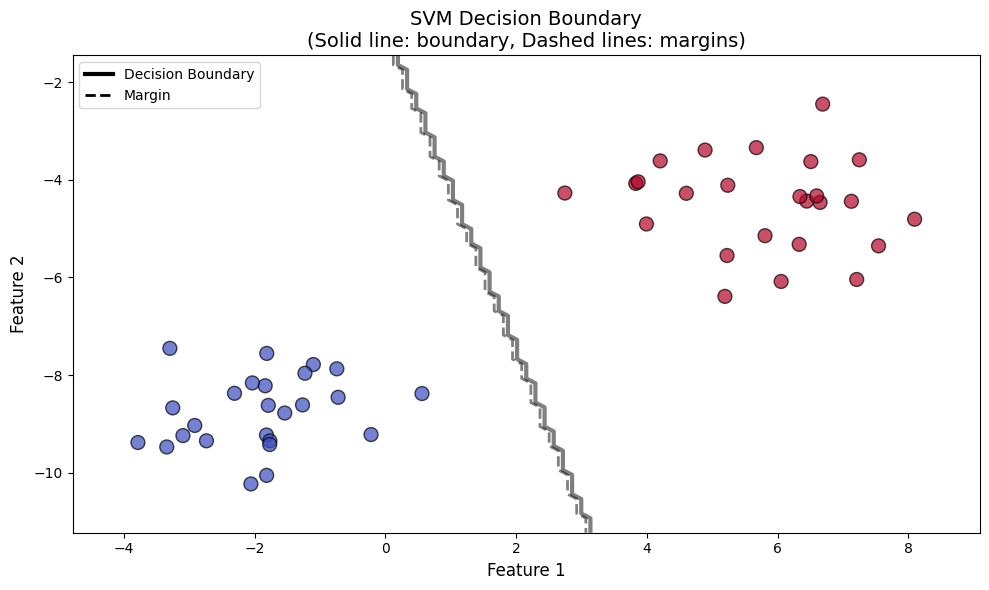


Decision boundary equation: 0.590*x1 + 0.179*x2 - -0.152 = 0


In [ ]:
# Visualize the SVM decision boundary and support vectors
def visualize_svm(X, y, clf):
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=100, cmap='coolwarm', edgecolors='k', alpha=0.7)
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Calculate decision function for each point in the mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'], linewidths=[2, 3, 2])
    
    # Add labels and title
    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title('SVM Decision Boundary\n(Solid line: boundary, Dashed lines: margins)', fontsize=14)
    legend_elements = [plt.Line2D([0], [0], color='k', linewidth=3, label='Decision Boundary'),
                      plt.Line2D([0], [0], color='k', linewidth=2, linestyle='--', label='Margin')]
    ax.legend(handles=legend_elements, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDecision boundary equation: {clf.w[0]:.3f}*x1 + {clf.w[1]:.3f}*x2 - {clf.b:.3f} = 0")

# Visualize the results
visualize_svm(X, y, clf)